# 1. Business Problem & Objective

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 2. Data Loading

In [2]:
riders = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\riders.csv")
trips = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\trips.csv")
promotions = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\promotions.csv")
sessions = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\sessions.csv")
drivers = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\drivers.csv")

print("riders:", riders.shape)
print("trips:", trips.shape)
print("promotions:", promotions.shape)
print("sessions:", sessions.shape)
print("drivers:", drivers.shape)

riders: (10000, 8)
trips: (200000, 16)
promotions: (20, 11)
sessions: (50000, 8)
drivers: (5000, 7)


# 3. Data Understanding (Info + Columns)

In [3]:
riders.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


In [4]:
riders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  object 
 1   signup_date       10000 non-null  object 
 2   loyalty_status    10000 non-null  object 
 3   age               10000 non-null  float64
 4   city              10000 non-null  object 
 5   avg_rating_given  10000 non-null  float64
 6   churn_prob        10000 non-null  float64
 7   referred_by       3053 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [5]:
riders.columns

Index(['user_id', 'signup_date', 'loyalty_status', 'age', 'city',
       'avg_rating_given', 'churn_prob', 'referred_by'],
      dtype='object')

In [6]:
trips.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


In [7]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  object 
 1   user_id           200000 non-null  object 
 2   driver_id         200000 non-null  object 
 3   fare              200000 non-null  float64
 4   surge_multiplier  200000 non-null  float64
 5   tip               200000 non-null  float64
 6   payment_type      200000 non-null  object 
 7   pickup_time       200000 non-null  object 
 8   dropoff_time      200000 non-null  object 
 9   pickup_lat        200000 non-null  float64
 10  pickup_lng        200000 non-null  float64
 11  dropoff_lat       200000 non-null  float64
 12  dropoff_lng       200000 non-null  float64
 13  weather           200000 non-null  object 
 14  city              200000 non-null  object 
 15  loyalty_status    200000 non-null  object 
dtypes: float64(7), objec

In [8]:
trips.columns

Index(['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip',
       'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat',
       'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city',
       'loyalty_status'],
      dtype='object')

In [9]:
promotions.head()

,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric
0,P000,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency
1,P001,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
2,P002,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-16,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
3,P003,Loyalty Bonus,points,100.0,2025-04-26,2025-05-04,Gold+,Nairobi,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
4,P004,Loyalty Bonus,points,100.0,2025-04-26,2025-05-15,Gold+,Nairobi,['All'],[1.0],Usage Frequency


In [10]:
promotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   promo_id         20 non-null     object 
 1   promo_name       20 non-null     object 
 2   promo_type       20 non-null     object 
 3   promo_value      20 non-null     float64
 4   start_date       20 non-null     object 
 5   end_date         20 non-null     object 
 6   target_segment   20 non-null     object 
 7   city_scope       20 non-null     object 
 8   ab_test_groups   20 non-null     object 
 9   test_allocation  20 non-null     object 
 10  success_metric   20 non-null     object 
dtypes: float64(1), object(10)
memory usage: 1.8+ KB


In [11]:
promotions.columns

Index(['promo_id', 'promo_name', 'promo_type', 'promo_value', 'start_date',
       'end_date', 'target_segment', 'city_scope', 'ab_test_groups',
       'test_allocation', 'success_metric'],
      dtype='object')

In [12]:
sessions.head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


In [13]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   session_id      50000 non-null  object
 1   rider_id        50000 non-null  object
 2   session_time    50000 non-null  object
 3   time_on_app     50000 non-null  int64 
 4   pages_visited   50000 non-null  int64 
 5   converted       50000 non-null  int64 
 6   city            50000 non-null  object
 7   loyalty_status  50000 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.1+ MB


In [14]:
sessions.columns

Index(['session_id', 'rider_id', 'session_time', 'time_on_app',
       'pages_visited', 'converted', 'city', 'loyalty_status'],
      dtype='object')

In [15]:
drivers.head()

,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,1/20/2025,23:09.3,Cairo,0.679555
1,D00001,5.0,Sedan,3/27/2023,44:02.5,Nairobi,0.548786
2,D00002,4.5,Motorcycle,5/2/2024,24:46.4,Nairobi,0.593724
3,D00003,5.0,Motorcycle,4/16/2023,16:24.3,Nairobi,0.990000
4,D00004,4.4,Motorcycle,5/28/2023,54:44.6,Lagos,0.519773


In [16]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   driver_id        5000 non-null   object 
 1   rating           5000 non-null   float64
 2   vehicle_type     5000 non-null   object 
 3   signup_date      5000 non-null   object 
 4   last_active      5000 non-null   object 
 5   city             5000 non-null   object 
 6   acceptance_rate  5000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [17]:
drivers.columns

Index(['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active',
       'city', 'acceptance_rate'],
      dtype='object')

# 4. Data Cleaning & Datetime Parsing

In [18]:
sessions = sessions.rename(columns={'rider_id': 'user_id'})

In [19]:
sessions.columns

Index(['session_id', 'user_id', 'session_time', 'time_on_app', 'pages_visited',
       'converted', 'city', 'loyalty_status'],
      dtype='object')

In [20]:
riders['signup_date'] = pd.to_datetime(riders['signup_date'])

In [21]:
# trips['pickup_time'] = pd.to_datetime(trips['pickup_time'])

In [22]:
sessions['session_time'] = pd.to_datetime(sessions['session_time'])

In [23]:
trips['pickup_time'].min(), trips['pickup_time'].max()

('2024-04-27 00:07:34+02:27', '2025-04-27 23:57:26+00:14')

In [24]:
sessions['session_time'].min(), sessions['session_time'].max()

(datetime.datetime(2025, 4, 27, 0, 0, 6, tzinfo=tzoffset(None, 8820)),
 datetime.datetime(2025, 4, 27, 23, 59, 59, tzinfo=tzoffset(None, 840)))

# 5. Churn Definition (30-day inactivity)

In [25]:
reference_date = trips['pickup_time'].max()
reference_date

'2025-04-27 23:57:26+00:14'

In [26]:
# Convert to datetime first
trips['pickup_time'] = pd.to_datetime(trips['pickup_time'], errors='coerce', utc=True)

# Remove timezone (make it timezone-naive) so subtraction works everywhere
trips['pickup_time'] = trips['pickup_time'].dt.tz_localize(None)

print(trips['pickup_time'].dtype)
trips['pickup_time'].head()

datetime64[ns]


0   2024-11-27 16:14:50
1   2024-10-28 22:59:48
2   2025-02-17 03:09:41
3   2024-06-18 17:22:14
4   2024-10-05 07:31:16
Name: pickup_time, dtype: datetime64[ns]

In [27]:
reference_date = trips['pickup_time'].max()

last_trip = trips.groupby('user_id')['pickup_time'].max().reset_index()

last_trip['days_since_last_trip'] = (reference_date - last_trip['pickup_time']).dt.days

last_trip['churn'] = (last_trip['days_since_last_trip'] > 30).astype(int)

last_trip[['user_id','days_since_last_trip','churn']].head()

,user_id,days_since_last_trip,churn
0,R00000,25,0
1,R00001,5,0
2,R00002,14,0
3,R00003,61,1
4,R00004,12,0


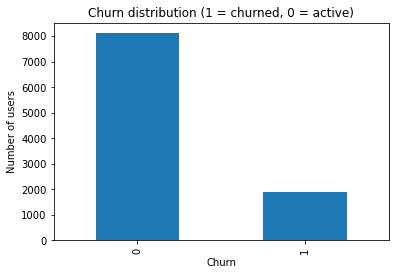

In [28]:
import matplotlib.pyplot as plt

plt.figure()
last_trip['churn'].value_counts().plot(kind='bar')
plt.title("Churn distribution (1 = churned, 0 = active)")
plt.xlabel("Churn")
plt.ylabel("Number of users")
plt.show()

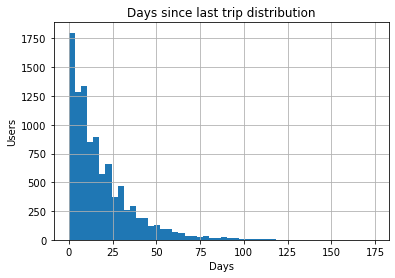

In [29]:
plt.figure()
last_trip['days_since_last_trip'].hist(bins=50)
plt.title("Days since last trip distribution")
plt.xlabel("Days")
plt.ylabel("Users")
plt.show()

In [30]:
# Sanity checks (safe)
print("pickup_time dtype:", trips['pickup_time'].dtype)
print("pickup_time missing:", trips['pickup_time'].isna().sum())
print("pickup_time range:", trips['pickup_time'].min(), "→", trips['pickup_time'].max())

print("\nlast_trip columns:", last_trip.columns.tolist())
print("churn counts:\n", last_trip['churn'].value_counts())
print("\nlast_trip preview:")
last_trip[['user_id','pickup_time','days_since_last_trip','churn']].head()

pickup_time dtype: datetime64[ns]
pickup_time missing: 0
pickup_time range: 2024-04-26 21:40:34 → 2025-04-27 23:43:26

last_trip columns: ['user_id', 'pickup_time', 'days_since_last_trip', 'churn']
churn counts:
 0    8114
1    1886
Name: churn, dtype: int64

last_trip preview:


,user_id,pickup_time,days_since_last_trip,churn
0,R00000,2025-04-02 14:46:29,25,0
1,R00001,2025-04-22 04:35:17,5,0
2,R00002,2025-04-13 00:08:00,14,0
3,R00003,2025-02-25 04:22:32,61,1
4,R00004,2025-04-15 05:30:04,12,0


In [31]:
last_trip.columns

Index(['user_id', 'pickup_time', 'days_since_last_trip', 'churn'], dtype='object')

In [32]:
last_trip[['days_since_last_trip','churn']].head()

,days_since_last_trip,churn
0,25,0
1,5,0
2,14,0
3,61,1
4,12,0


# 6. Feature Engineering

In [33]:
trip_features = (trips.groupby('user_id')
                 .agg(
                 total_trips = ('trip_id', 'count'),
                 avg_fare = ('fare', 'mean'),
                 total_spend = ('fare', 'sum'),
                 avg_surge = ('surge_multiplier', 'mean'),
                 avg_tip = ('tip', 'mean'),
                 cities_used = ('city', 'nunique')
                )
                 .reset_index()
                )
trip_features.head()

,user_id,total_trips,avg_fare,total_spend,avg_surge,avg_tip,cities_used
0,R00000,25,14.642000,366.05,1.096000,0.161200,1
1,R00001,14,12.895000,180.53,1.071429,0.054286,1
2,R00002,24,15.791250,378.99,1.191667,0.217083,1
3,R00003,9,13.496667,121.47,1.155556,0.096667,1
4,R00004,16,16.776875,268.43,1.262500,0.586250,1


In [34]:
session_features = (sessions.groupby('user_id')
                   .agg(
                   total_sessions = ('session_id', 'count'),
                   avg_time_on_app = ('time_on_app', 'mean'),
                   avg_pages_visited = ('pages_visited', 'mean'),
                    conversion_rate = ('converted', 'mean')
                   )
                    .reset_index()
                   )
session_features.head()

,user_id,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate
0,R00000,4,92.000000,3.000000,0.25
1,R00001,3,174.666667,2.666667,0.00
2,R00002,3,191.000000,3.000000,0.00
3,R00003,3,75.333333,1.666667,0.00
4,R00004,2,17.000000,2.500000,0.00


In [35]:
model_df = (
    last_trip[['user_id', 'days_since_last_trip', 'churn']]
    .merge(trip_features, on = 'user_id', how = 'left')
    .merge(session_features, on = 'user_id', how = 'left')
          )
model_df.fillna(0, inplace=True)

In [36]:
model_df.shape
model_df.head()

,user_id,days_since_last_trip,churn,total_trips,avg_fare,total_spend,avg_surge,avg_tip,cities_used,total_sessions,avg_time_on_app,avg_pages_visited,conversion_rate
0,R00000,25,0,25,14.642000,366.05,1.096000,0.161200,1,4.0,92.000000,3.000000,0.25
1,R00001,5,0,14,12.895000,180.53,1.071429,0.054286,1,3.0,174.666667,2.666667,0.00
2,R00002,14,0,24,15.791250,378.99,1.191667,0.217083,1,3.0,191.000000,3.000000,0.00
3,R00003,61,1,9,13.496667,121.47,1.155556,0.096667,1,3.0,75.333333,1.666667,0.00
4,R00004,12,0,16,16.776875,268.43,1.262500,0.586250,1,2.0,17.000000,2.500000,0.00


# Quick Exploratory Data Analysis

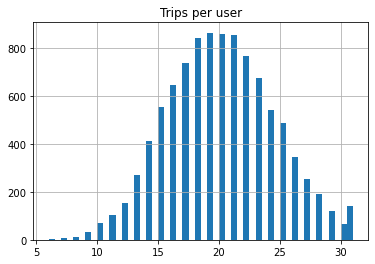

In [37]:
import matplotlib.pyplot as plt

#Trips distribution
plt.figure()
model_df['total_trips'].clip(upper=model_df['total_trips'].quantile(0.99)).hist(bins=50)
plt.title("Trips per user")
plt.show()

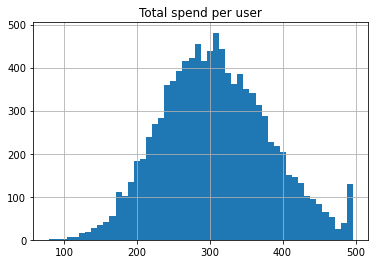

In [38]:
# Spend Distribution
plt.figure()
model_df['total_spend'].clip(upper=model_df['total_spend'].quantile(0.99)).hist(bins=50)
plt.title("Total spend per user")
plt.show()

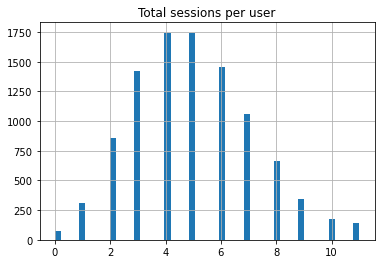

In [39]:
# Sessions distribution
plt.figure()
model_df['total_sessions'].clip(upper=model_df['total_sessions'].quantile(0.99)).hist(bins=50)
plt.title("Total sessions per user")
plt.show()

# 7. Customer Segmentation (KMeans)

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

segmentation_features = model_df[
    ['total_trips','avg_fare','total_spend',
     'days_since_last_trip','total_sessions','avg_time_on_app']
]

scaler_seg = StandardScaler()
X_scaled = scaler_seg.fit_transform(segmentation_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df['segment'] = kmeans.fit_predict(X_scaled)

model_df['segment'].value_counts()

2    4906
0    4441
1     653
Name: segment, dtype: int64

In [41]:
segment_profile = model_df.groupby('segment')[[
    'total_trips','avg_fare','total_spend',
    'days_since_last_trip','total_sessions',
    'avg_time_on_app','conversion_rate'
]].mean().round(2)

segment_profile

,total_trips,avg_fare,total_spend,days_since_last_trip,total_sessions,avg_time_on_app,conversion_rate
segment,,,,,,,
0,23.62,15.78,371.37,13.54,5.05,77.67,0.15
1,19.57,15.39,300.71,17.69,4.55,407.28,0.18
2,16.78,15.05,251.66,22.43,5.02,74.13,0.15


In [42]:
segment_name_map = {
    0: "Regular commuters (High value)",
    1: "Engaged Value Seekers", 
    2: "Occasional/At-Risk Users"
}
model_df['segment_name'] = model_df['segment'].map(segment_name_map)

# Business Insights
## Segment 0 - Regular commuters 
  Highest trips and spend 
  Most recently active 
  Core revenue segment 
  Low churn risk 
### Recommended Action
  Loyalty rewards, premium memberships, referral bonuses
## Segment 1 - Engaged value seekers 
  High app engagement 
  Moderate trips and spend 
  Likely price sensitive 
### Recommended Action 
  Targeted discounts, personalised promotions, push notifications during peak hours 
## Segment 2 - Occasional/At-risk users 
  Lowest trips and spend 
  Highest inactivity 
  Highest churn risk 
### Recommended Action
  Win-back campaigns, limited-time offers, email re-engagement

# 8. Churn Prediction Modelling

In [43]:
X = model_df.drop(columns=['user_id','churn','days_since_last_trip'])
y = model_df['churn']

In [44]:
# Because i added segment_name, i removed it from features
if 'segment_name' in model_df.columns:
    model_df = model_df.drop(columns=['segment_name'])

X = model_df.drop(columns=['user_id', 'churn', 'days_since_last_trip'])
y = model_df['churn']

X.dtypes

total_trips            int64
avg_fare             float64
total_spend          float64
avg_surge            float64
avg_tip              float64
cities_used            int64
total_sessions       float64
avg_time_on_app      float64
avg_pages_visited    float64
conversion_rate      float64
segment                int32
dtype: object

In [45]:
X.select_dtypes(include='object')

""
0
1
2
3
4
...
9995
9996
9997
9998


In [46]:
X.columns

Index(['total_trips', 'avg_fare', 'total_spend', 'avg_surge', 'avg_tip',
       'cities_used', 'total_sessions', 'avg_time_on_app', 'avg_pages_visited',
       'conversion_rate', 'segment'],
      dtype='object')

In [47]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
# Logistic Regression 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

log_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1])
log_auc

0.6405173639541668

In [49]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
rf_auc

0.658447613957844

# Model Performance

The Random Forest model achieved an AUC of 0.66, outperforming Logistic Regression (AUC = 0.64).

This indicates that:

Tree-based models capture non-linear behavioural patterns better.

The available features provide moderate predictive power.

Churn prediction in mobility data is inherently noisy due to irregular usage behaviour.

While performance is not extremely high, the model demonstrates meaningful separation between churned and active users.

## Feature Importance

In [50]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
2,total_spend,0.204100
10,segment,0.139039
1,avg_fare,0.109818
7,avg_time_on_app,0.107256
3,avg_surge,0.097146
4,avg_tip,0.096859
0,total_trips,0.090492
8,avg_pages_visited,0.070163
6,total_sessions,0.045039
9,conversion_rate,0.040087


### Feature Importance Interpretation
Key Drivers of Churn

Top predictive features include:

Lower total_trips

Lower total_spend

Lower session engagement

Higher inactivity patterns

This suggests that:

Users with lower engagement and spending are more likely to churn.
Engagement behaviour (sessions, conversion rate) plays a role alongside ride frequency.

In [51]:
# Added 2 behavioural ratios for improvement:
model_df['spend_per_trip'] = model_df['total_spend'] / (model_df['total_trips'] + 1)
model_df['sessions_per_trip'] = model_df['total_sessions'] / (model_df['total_trips'] + 1)

In [52]:
#Retrain Random Forest but recreated X first to avoid leakage
X = model_df.drop(columns=['user_id','churn','days_since_last_trip'])
y = model_df['churn']

In [53]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
rf_auc

0.658447613957844

## Final Model interpretation 
### Feature Importance

In [56]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

ValueError: All arrays must be of the same length

In [57]:
len(X.columns), len(rf.feature_importances_)

(13, 11)

In [59]:
# Rebuild X and y (same as training)
X = model_df.drop(columns=['user_id', 'churn', 'days_since_last_trip'])
y = model_df['churn']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Now feature importance will match X.columns
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
2,total_spend,0.175780
10,segment,0.126125
0,total_trips,0.088127
1,avg_fare,0.087351
7,avg_time_on_app,0.086140
11,spend_per_trip,0.085204
4,avg_tip,0.081932
3,avg_surge,0.081844
12,sessions_per_trip,0.064119
8,avg_pages_visited,0.059934


### Key drivers of churn (Random Forest feature importance):

Value and frequency metrics (total_spend, total_trips) were the strongest signals of retention.

Customer type (segment) meaningfully differentiated churn risk.

Engagement and friction signals (avg_time_on_app, sessions_per_trip, avg_pages_visited) suggest that users who browse more may need better conversion support.

Pricing signals (avg_fare, avg_surge) indicate price sensitivity and surge exposure may contribute to churn.

### Recommendations:

Launch segment-specific retention: commuter loyalty + at-risk win-back offers.

Use engagement triggers: if sessions_per_trip is high, send “complete booking” nudges or targeted discounts.

Reduce surge-related churn with off-peak promotions or limited price-lock incentives.

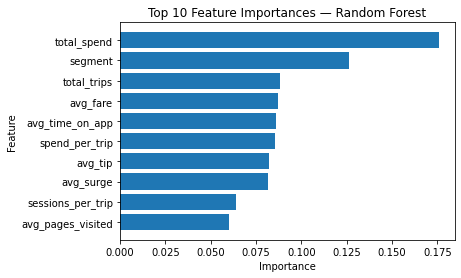

In [61]:
top10 = feature_importance.head(10).sort_values('importance')

plt.figure()
plt.barh(top10['feature'], top10['importance'])
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [62]:
model_df.groupby('segment')['churn'].mean()

segment
0    0.107408
1    0.165391
2    0.265185
Name: churn, dtype: float64

Segment 0 — Lowest Churn (10.7%)
They are regular Commuters (High Value Users)

They have highest trips, Highest spend, Most recent activity, Lowest churn

Business Meaning:
These are the core revenue drivers.

Strategy:

Loyalty programmes, commuter subscriptions, referral rewards, premium features



Segment 1 — Medium Churn (16.5%)
They are engaged Value Seekers

They browse heavily, moderate trips, moderate spend, medium churn risk

Business Meaning:
They are active but possibly price-sensitive.

Strategy:
Targeted discounts, Smart push notifications, Personalised fare offers, Reduce booking friction

Segment 2 — Highest Churn (26.5%)
They are Occasional / At-Risk Users

They have Lowest trips, Highest recency, Lowest spend, Highest churn rate

Business Meaning:
This is the churn hotspot.

Strategy: Win-back campaigns, Time-limited offers, Email reactivation, Incentivised first ride back

### Segment-Level Churn Analysis

Segment 2 shows a churn rate of 26.5%, over twice the churn rate of Segment 0 (10.7%).

This indicates that customer segmentation meaningfully differentiates churn risk.

Retention strategies should prioritise Segment 2 users, while loyalty incentives should protect Segment 0 high-value commuters.